# Workflow Pattern: Routing

Routing is a pattern where an LLM (or small router agent) **classifies or interprets incoming input** and then **routes it to the appropriate sub-process** or agent. This design is helpful when you're dealing with **multiple types of tasks or user intents**, and you want specialized logic or handling for each case.

It works like a switchboard — one intelligent node (a classifier or router) analyzes the input and directs it to the correct branch.

#### Use Cases:
- AI customer service bots (route billing, tech support, or general inquiries)
- Multi-skill agents (for example, summarization, translation, and data extraction)
- Adaptive education bots (route to math, science, or grammar modules)

---

#### Routing Techniques:
1. **Hard-coded keyword-based routing** (primitive)
2. **LLM-based routing** using classification prompts
3. **Embedding-based semantic matching** with a routing map

---


<img src='../assets/routing.png' />

## Routing — Task Classifier for Summarization and Translation

In [6]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph
from IPython.display import Image, display

In [2]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str

In [ ]:
class Router(BaseModel):
    # role: str = Field(..., description="Decide whether the user wants to summarize a passage, then output 'summarize'  or translate text into Urdu, then output 'translate' and if you do not know, output 'default_handler'")
    role: Literal["summarize", "translate", "default_handler"] = Field(..., description="Decide whether the user wants to summarize or translate. and if don't knoe then default_handler")
    ### First "role" definition could also be used. But somethimes, it do not return result as expected.

llm_router=llm.bind_tools([Router])

In [37]:
response=llm_router.invoke("summarize this I love the sun its so warm")
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_wYxOc1h7D8wOWBp9p7iQlqys', 'function': {'arguments': '{"role":"summarize"}', 'name': 'Router'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 79, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_414ba99a04', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-d5d4167e-e37b-4b50-933d-85ab5b29a622-0', tool_calls=[{'name': 'Router', 'args': {'role': 'summarize'}, 'id': 'call_wYxOc1h7D8wOWBp9p7iQlqys', 'type': 'tool_call'}], usage_metadata={'input_tokens': 79, 'output_tokens': 15, 'total_tokens': 94})

In [38]:
def router_node(state: RouterState) -> RouterState:
    routing_prompt = f"""
    You are an AI task classifier.
    
    Decide whether the user wants to:
    - "summarize" a passage
    - or "translate" text into Urdu
    - or if you don't know, then say "default_handler"
    
    Respond with just one word: 'summarize' or 'translate' or 'default_handler'.
    
    User Input: "{state['user_input']}"
    """

    response = llm_router.invoke(routing_prompt)

    return {**state, "task_type": response.tool_calls[0]['args']['role']} # This becomes the next node's name!

In [39]:
def router(state: RouterState) -> str:
    print('task_type to execute: ', state['task_type'])
    return state['task_type']

In [40]:
def summarize_node(state: RouterState) -> RouterState:
    prompt = f"Please summarize the following passage:\n\n{state['user_input']}"
    response = llm.invoke(prompt)
    
    return {**state, "task_type": "summarize", "output": response.content}

In [41]:
def translate_node(state: RouterState) -> RouterState:
    prompt = f"Translate the following text to Urdu:\n\n{state['user_input']}"
    response = llm.invoke(prompt)

    return {**state, "task_type": "translate", "output": response.content}

In [42]:
def default_handler_node(state: RouterState) -> RouterState:
    prompt = f"""
    I couldn't classify your request into a specific category. 
    Let me provide general assistance for: "{state['user_input']}"
    
    I can help you with:
    - Summarize text
    - Translate text into Urdu
    
    Please rephrase your request to match one of these services.
    
    Would you like me to:
    1. Help you rephrase your request for one of our services
    """
    response = llm.invoke(prompt) # Here we can also replace llm call with direct output
    return {**state, "task_type": "default_handler", "output": response.content.strip()}

In [57]:
workflow = StateGraph(RouterState)

workflow.add_node("router", router_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("translate", translate_node)
workflow.add_node("default_handler", default_handler_node)

workflow.set_entry_point("router")
workflow.add_conditional_edges("router", router, {
    "summarize": "summarize",
    "translate": "translate",
    "default_handler": "default_handler"
    },
)
workflow.set_finish_point("summarize")
workflow.set_finish_point("translate")
workflow.set_finish_point("default_handler")

app = workflow.compile()


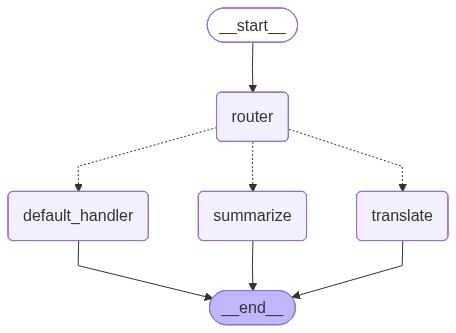

In [52]:
display(Image(app.get_graph().draw_mermaid_png()))

In [45]:
input_text = {
        "user_input": "Can you translate this sentence: I love programming?"
    }

result = app.invoke(input_text)

task_type to execute:  translate


In [46]:
print(result['output'])
print(result['task_type'])

Sure! The translation of "I love programming" in Urdu is: "مجھے پروگرامنگ سے محبت ہے۔"
translate


In [47]:
input_text = {
        "user_input": "Can you summarize this sentence: I love programming so much it is the best thing ever. All I want to do is programming?"
    }

result = app.invoke(input_text)

task_type to execute:  summarize


In [48]:
print(result['output'])
print(result['task_type'])

The author is passionate about programming and considers it the best activity, expressing a strong desire to focus solely on it.
summarize


In [49]:
input_text = {
        "user_input": "What's the weather today?"
    }

result = app.invoke(input_text)

task_type to execute:  default_handler


In [50]:
print(result['output'])
print(result['task_type'])

It seems there was a misunderstanding. If you would like assistance with a specific task, please let me know how I can help you. For example, if you need a summary or a translation into Urdu, just provide the text you'd like assistance with.
default_handler
